## Blood Pressure Prediction

This notebook trains models to predict SBP and DBP from ECG and PPG waveforms. Models are evaluated on both calibration-based and calibration-free test sets. Calibration-free evaluation is more challenging because test subjects are not seen during training.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.optim as optim
import matplotlib.pyplot as plt
!pip -q install kneed
from kneed import KneeLocator
import gc, time
from google.colab import drive
import sys
from pathlib import Path
from sklearn.metrics import r2_score

pd.set_option('display.width', 200)

drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/cuffless-bp-pulsedb")
PROCESSED_DIR = PROJECT_DIR / "processed"
RESULTS_DIR = PROJECT_DIR / "results"
FIG_DIR = PROJECT_DIR / "figures"

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

from src.models import (
    FCNN,
    CNN1D,
    RNN,
    Transformer
)

from src.train import (
    plot_true_vs_pred,
    make_features,
    compute_bp_metrics,
    PulseDataset,
    evaluate_model,
)

Mounted at /content/drive


In [ ]:
df_train = pd.read_csv(f"{PROCESSED_DIR}/train_meta.csv")
ECG_train = np.load(f"{PROCESSED_DIR}/train_ecg.npy")
PPG_train = np.load(f"{PROCESSED_DIR}/train_ppg.npy")
train_idx = np.load(f"{PROCESSED_DIR}/train_idx.npy")
val_idx = np.load(f"{PROCESSED_DIR}/val_idx.npy")

df_val = df_train.iloc[val_idx]
ECG_val = ECG_train[val_idx]
PPG_val = PPG_train[val_idx]

df_train = df_train.iloc[train_idx]
ECG_train = ECG_train[train_idx]
PPG_train = PPG_train[train_idx]

df_calbased = pd.read_csv(f"{PROCESSED_DIR}/calbased_meta.csv")
ECG_calbased = np.load(f"{PROCESSED_DIR}/calbased_ecg.npy")
PPG_calbased = np.load(f"{PROCESSED_DIR}/calbased_ppg.npy")

df_calfree = pd.read_csv(f"{PROCESSED_DIR}/calfree_meta.csv")
ECG_calfree = np.load(f"{PROCESSED_DIR}/calfree_ecg.npy")
PPG_calfree = np.load(f"{PROCESSED_DIR}/calfree_ppg.npy")

print(ECG_train.shape, ECG_val.shape, ECG_calbased.shape, ECG_calfree.shape)
print(PPG_train.shape, PPG_val.shape, PPG_calbased.shape, PPG_calfree.shape)
print(df_train.shape, df_val.shape, df_calbased.shape, df_calfree.shape)

(415062, 1250) (46367, 1250) (51288, 1250) (57521, 1250)
(415062, 1250) (46367, 1250) (51288, 1250) (57521, 1250)
(415062, 8) (46367, 8) (51288, 8) (57521, 8)


In [ ]:
def standardize_inplace(X, mean, std):
    X -= mean
    X /= std
    return X

signal_stats = pd.read_csv(PROCESSED_DIR / "signal_stats.csv").iloc[0]

ecg_mean = float(signal_stats["ecg_mean"])
ecg_std = float(signal_stats["ecg_std"])
ppg_mean = float(signal_stats["ppg_mean"])
ppg_std = float(signal_stats["ppg_std"])

ECG_train = standardize_inplace(ECG_train.astype("float32", copy=False), ecg_mean, ecg_std)
PPG_train = standardize_inplace(PPG_train.astype("float32", copy=False), ppg_mean, ppg_std)

ECG_val = standardize_inplace(ECG_val.astype("float32", copy=False), ecg_mean, ecg_std)
PPG_val = standardize_inplace(PPG_val.astype("float32", copy=False), ppg_mean, ppg_std)

ECG_calbased = standardize_inplace(ECG_calbased.astype("float32", copy=False), ecg_mean, ecg_std)
PPG_calbased = standardize_inplace(PPG_calbased.astype("float32", copy=False), ppg_mean, ppg_std)

ECG_calfree = standardize_inplace(ECG_calfree.astype("float32", copy=False), ecg_mean, ecg_std)
PPG_calfree = standardize_inplace(PPG_calfree.astype("float32", copy=False), ppg_mean, ppg_std)

In [ ]:
metrics_path = RESULTS_DIR / "metrics.csv"

,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,Ridge Regression,calbased,SBP,-0.038417,17.919249,14.211845,0.074317,205.863158,None
1,Ridge Regression,calbased,DBP,-0.031211,11.278760,8.975644,0.098215,205.863158,None


,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,Ridge Regression,calfree,SBP,0.321489,17.882399,14.290911,0.078753,205.863158,None
1,Ridge Regression,calfree,DBP,0.070565,11.353824,9.029755,0.075383,205.863158,None


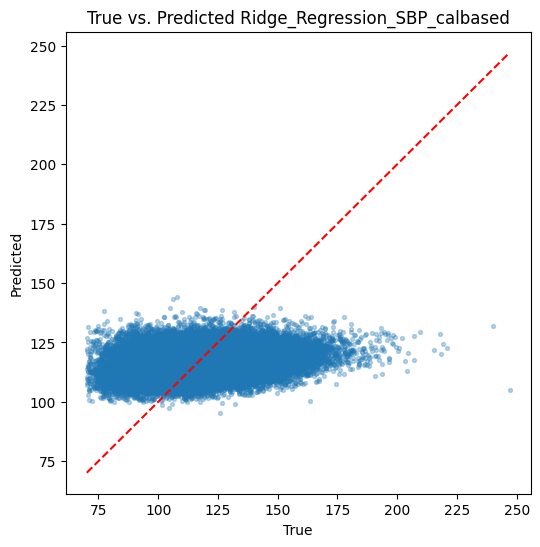

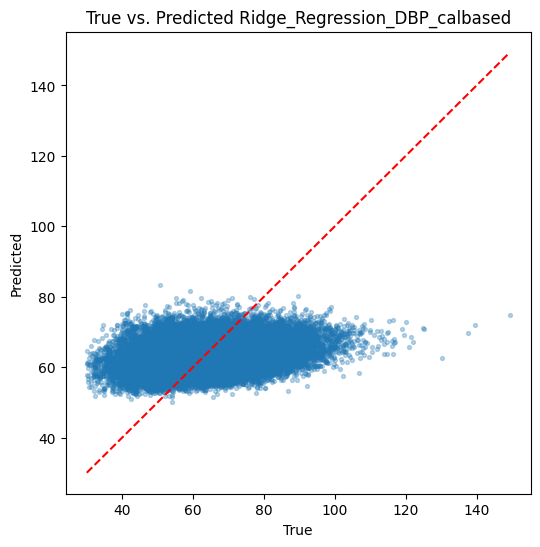

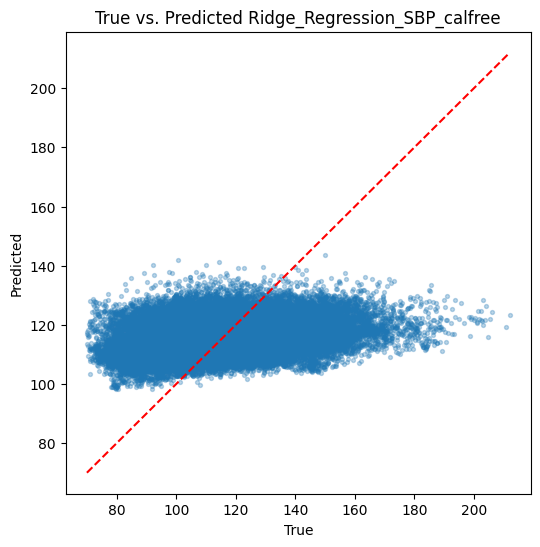

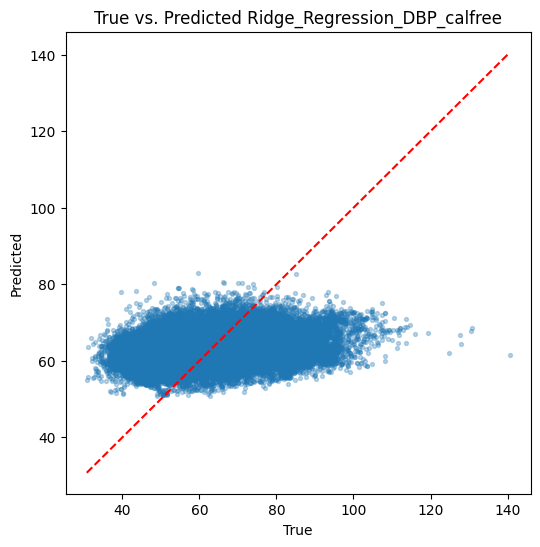

9609

In [ ]:
# Linear regression (Ridge) baseline

X_train_lr = make_features(ECG_train, PPG_train)
y_train_lr = df_train[["SBP", "DBP"]].to_numpy(dtype="float32")

X_calbased_lr = make_features(ECG_calbased, PPG_calbased)
y_calbased = df_calbased[["SBP", "DBP"]].to_numpy(dtype="float32")

X_calfree_lr = make_features(ECG_calfree, PPG_calfree)
y_calfree = df_calfree[["SBP", "DBP"]].to_numpy(dtype="float32")

start = time.time()
linear_model = Ridge(alpha=1.0)  # Ridge(alpha=1.0) or LinearRegression()
linear_model.fit(X_train_lr, y_train_lr)
train_time = time.time() - start

y_pred_calbased = linear_model.predict(X_calbased_lr)
y_pred_calfree = linear_model.predict(X_calfree_lr)

linear_metrics = compute_bp_metrics(
    model_name="Ridge Regression",
    split_name="calbased",
    y_true=y_calbased,
    y_pred=y_pred_calbased,
    train_time=train_time,
    n_epochs=None,
    metrics_path=metrics_path,
)

display(linear_metrics)

linear_metrics_free = compute_bp_metrics(
    model_name="Ridge Regression",
    split_name="calfree",
    y_true=y_calfree,
    y_pred=y_pred_calfree,
    train_time=train_time,
    n_epochs=None,
    metrics_path=metrics_path,
)

display(linear_metrics_free)

plot_true_vs_pred(df_calbased["SBP"], y_pred_calbased[:, 0], "Ridge Regression", "calbased", "SBP", fig_dir=FIG_DIR)
plot_true_vs_pred(df_calbased["DBP"], y_pred_calbased[:, 1], "Ridge Regression", "calbased", "DBP", fig_dir=FIG_DIR)
plot_true_vs_pred(df_calfree["SBP"], y_pred_calfree[:, 0], "Ridge Regression", "calfree", "SBP", fig_dir=FIG_DIR)
plot_true_vs_pred(df_calfree["DBP"], y_pred_calfree[:, 1], "Ridge Regression", "calfree", "DBP", fig_dir=FIG_DIR)

del X_train_lr, X_calbased_lr, y_train_lr, y_calbased, y_pred_calbased, X_calfree_lr, y_calfree, y_pred_calfree
gc.collect()

In [ ]:
train_dataset = PulseDataset(ECG_train, PPG_train, df_train)
val_dataset = PulseDataset(ECG_val, PPG_val, df_val)
test_dataset = PulseDataset(ECG_calbased, PPG_calbased, df_calbased)
test_dataset_free = PulseDataset(ECG_calfree, PPG_calfree, df_calfree)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)
test_loader_free = DataLoader(test_dataset_free, batch_size=1024, shuffle=False)

In [ ]:
def run_model(model_list, train_loader, val_loader, test_loader, test_loader_free):
    for name, model_class in model_list:
        SBP_pred, DBP_pred, SBP_pred_free, DBP_pred_free, train_time, n_epochs, all_training_loss, all_val_loss = evaluate_model(
            name,
            model_class,
            train_loader,
            val_loader,
            test_loader,
            test_loader_free
        )

        y_true = df_calbased[["SBP", "DBP"]].to_numpy(dtype="float32")
        y_pred = np.column_stack([SBP_pred, DBP_pred])
        y_true_free = df_calfree[["SBP", "DBP"]].to_numpy(dtype="float32")
        y_pred_free = np.column_stack([SBP_pred_free, DBP_pred_free])

        metrics = compute_bp_metrics(
            model_name=name,
            split_name="calbased",
            y_true=y_true,
            y_pred=y_pred,
            train_time=train_time,
            n_epochs=n_epochs,
            metrics_path=metrics_path,
        )

        display(metrics)

        metrics_free = compute_bp_metrics(
            model_name=name,
            split_name="calfree",
            y_true=y_true_free,
            y_pred=y_pred_free,
            train_time=train_time,
            n_epochs=n_epochs,
            metrics_path=metrics_path,
        )

        display(metrics_free)

        plt.figure(figsize=(8, 5))
        plt.plot(all_training_loss, label="Train Loss")
        plt.plot(all_val_loss, label="Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"Training Curve ({name})")
        plt.legend()
        plt.grid(True)
        plt.savefig(FIG_DIR / f"{name}_training_curve.png", dpi=300, bbox_inches="tight")
        plt.show()

        plot_true_vs_pred(df_calbased["SBP"], SBP_pred, name, "calbased", "SBP", fig_dir=FIG_DIR)
        plot_true_vs_pred(df_calbased["DBP"], DBP_pred, name, "calbased", "DBP", fig_dir=FIG_DIR)
        plot_true_vs_pred(df_calfree["SBP"], SBP_pred_free, name, "calfree", "SBP", fig_dir=FIG_DIR)
        plot_true_vs_pred(df_calfree["DBP"], DBP_pred_free, name, "calfree", "DBP", fig_dir=FIG_DIR)

        del SBP_pred, DBP_pred, SBP_pred_free, DBP_pred_free, train_time, n_epochs, all_training_loss, all_val_loss, metrics, metrics_free
        gc.collect()

,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,FCNN,calbased,SBP,-0.368225,17.434536,13.705942,0.123332,744.74321,49
1,FCNN,calbased,DBP,0.292592,11.275326,8.949271,0.098164,744.74321,49


,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,FCNN,calfree,SBP,-0.276861,17.922197,14.169864,0.074726,744.74321,49
1,FCNN,calfree,DBP,0.263084,11.771340,9.345952,0.005673,744.74321,49


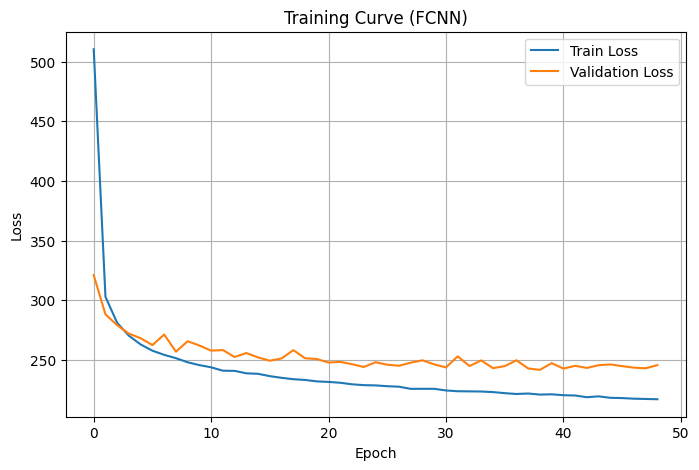

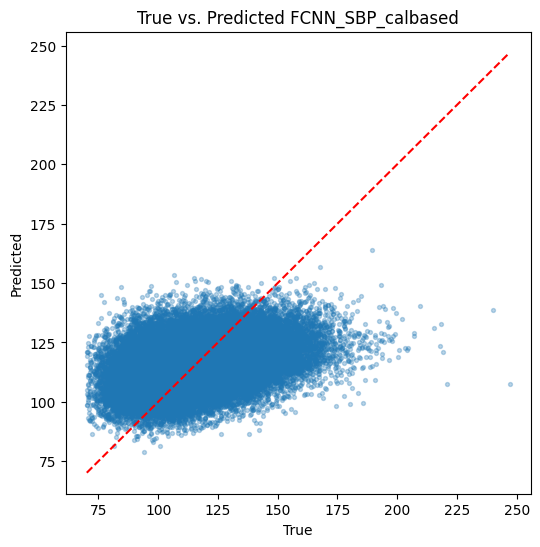

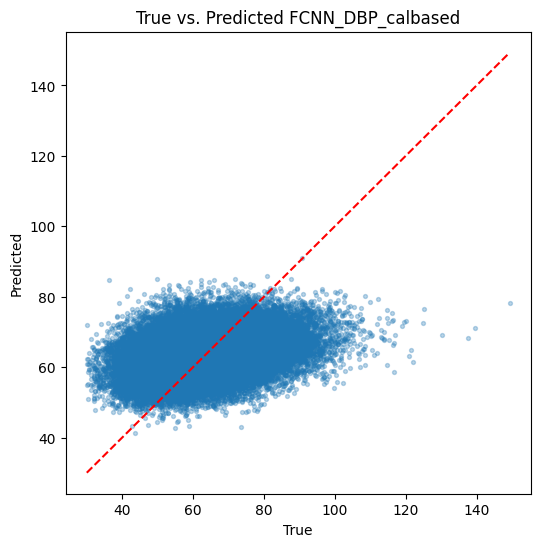

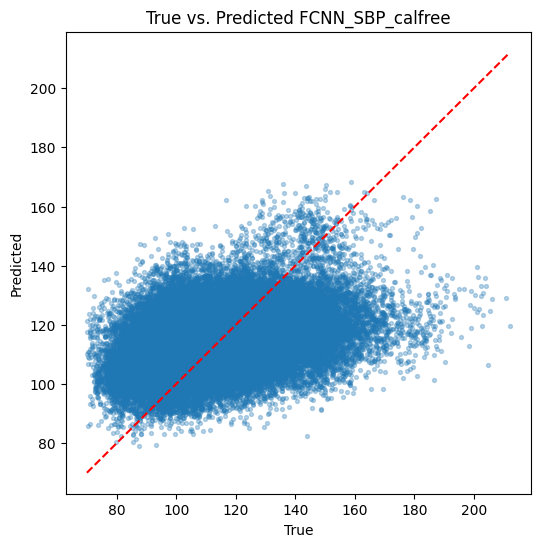

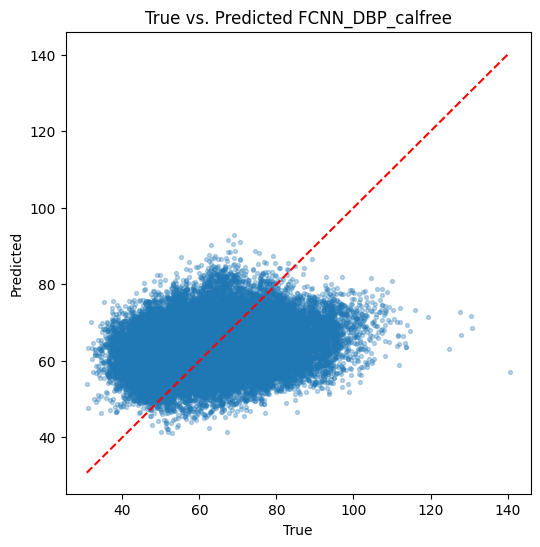

,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,1D CNN,calbased,SBP,1.133685,15.014558,11.913191,0.346396,1816.932378,38
1,1D CNN,calbased,DBP,-1.311453,9.879764,7.844209,0.295865,1816.932378,38


,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,1D CNN,calfree,SBP,0.569354,15.999843,12.695709,0.261815,1816.932378,38
1,1D CNN,calfree,DBP,-1.702045,10.176126,8.142860,0.236501,1816.932378,38


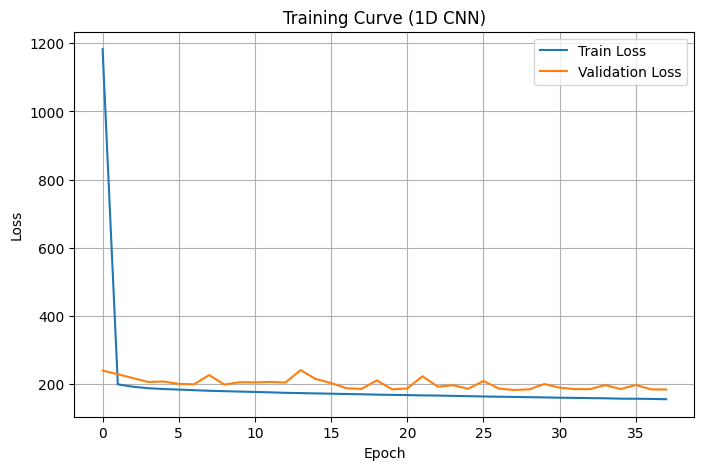

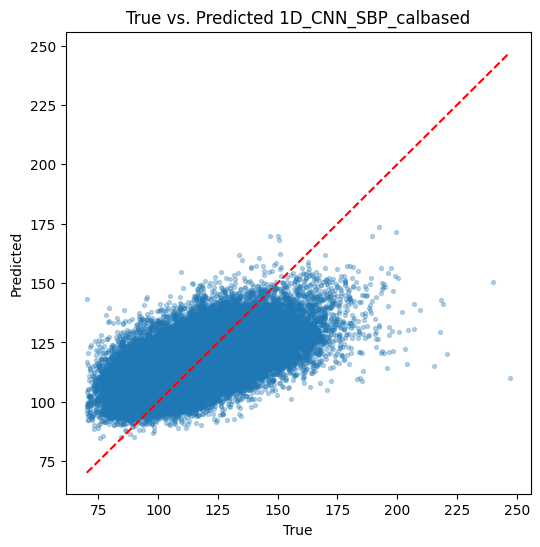

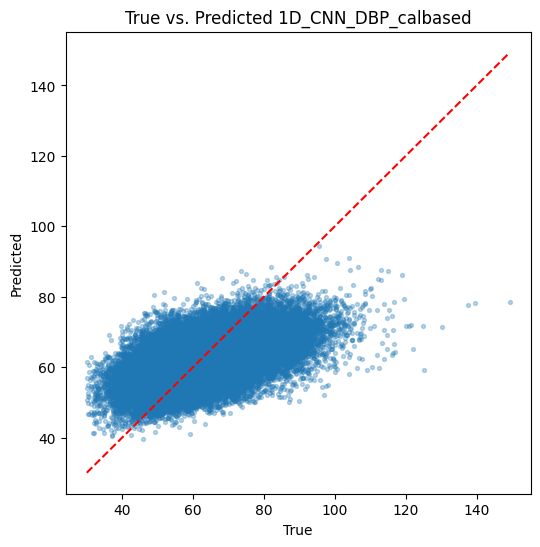

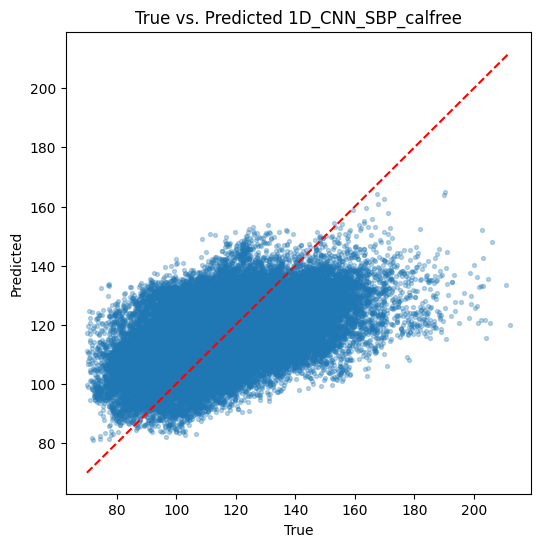

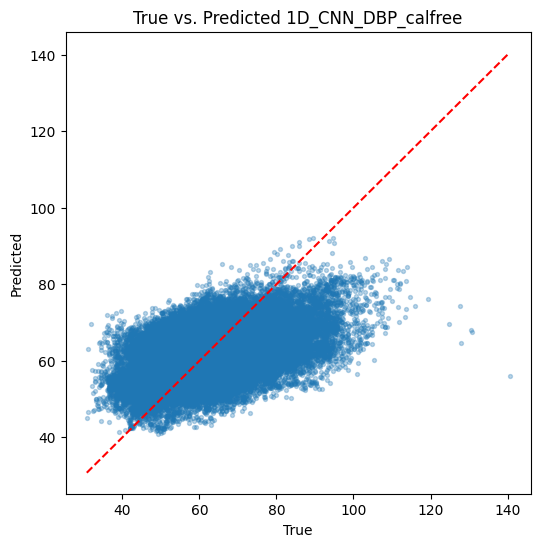

,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,GRU,calbased,SBP,-0.717708,14.841511,11.619498,0.363511,2057.256566,45
1,GRU,calbased,DBP,-0.358086,10.007301,7.896009,0.289168,2057.256566,45


,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,GRU,calfree,SBP,-1.184578,15.885607,12.486625,0.269197,2057.256566,45
1,GRU,calfree,DBP,-0.784633,10.312982,8.137671,0.232752,2057.256566,45


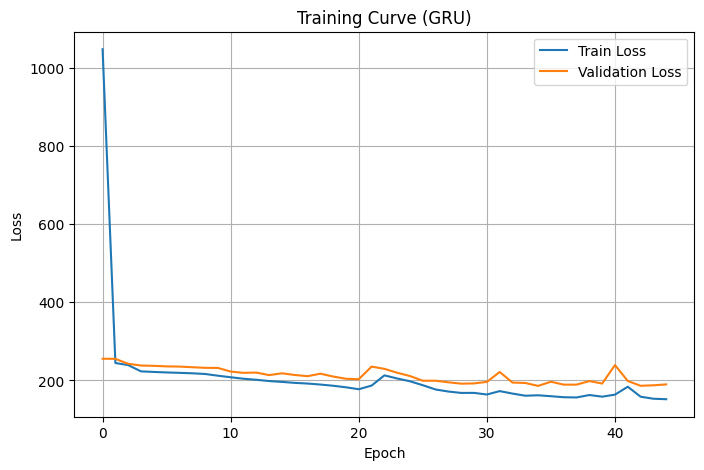

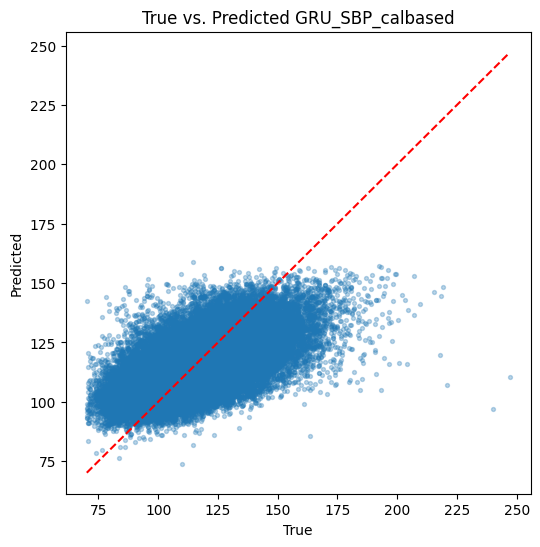

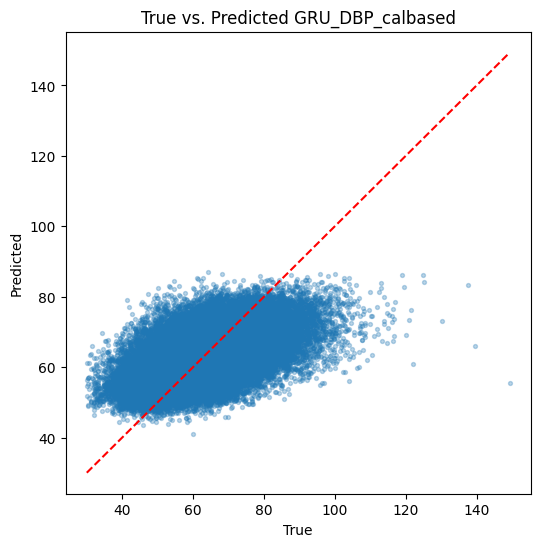

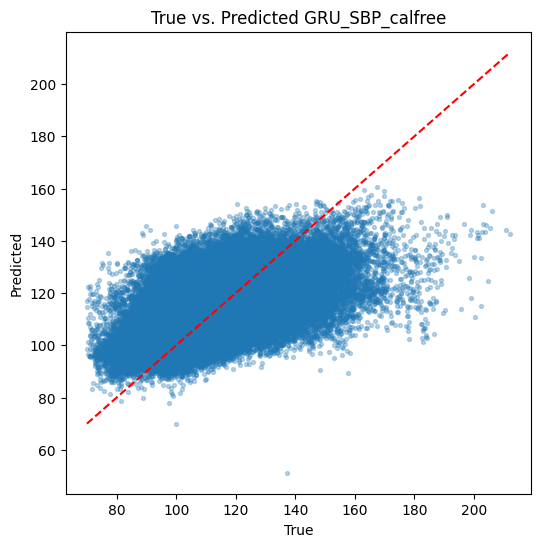

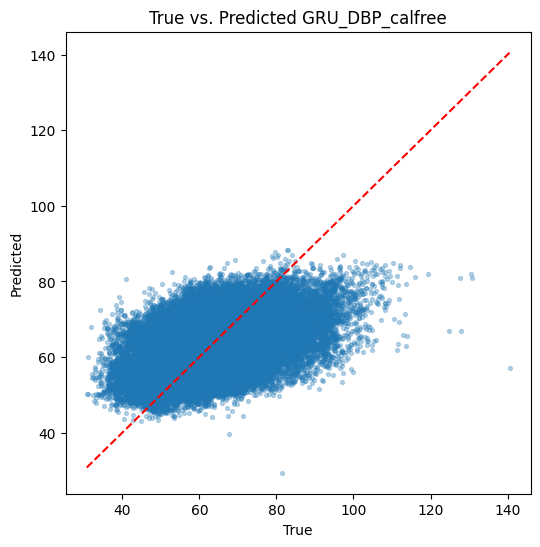

,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,RNN,calbased,SBP,0.532923,18.595251,14.830302,0.002343,508.934283,21
1,RNN,calbased,DBP,0.160555,11.836111,9.416296,0.006712,508.934283,21


,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,RNN,calfree,SBP,0.805594,18.584867,14.902773,0.003405,508.934283,21
1,RNN,calfree,DBP,0.204059,11.772732,9.374174,0.005636,508.934283,21


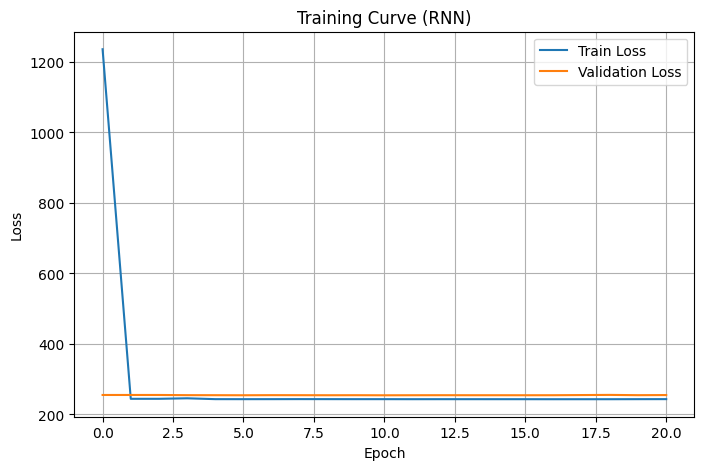

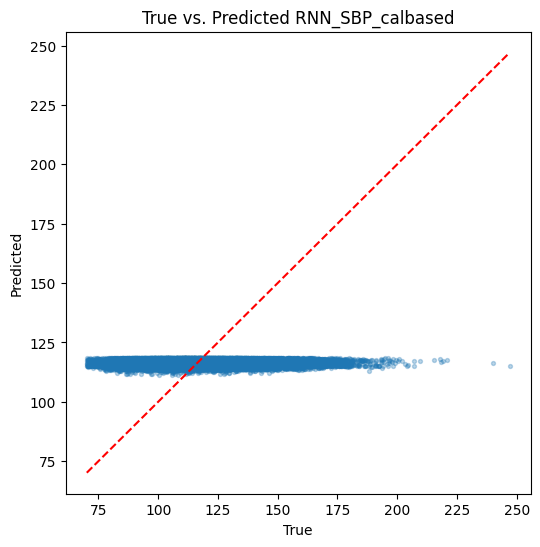

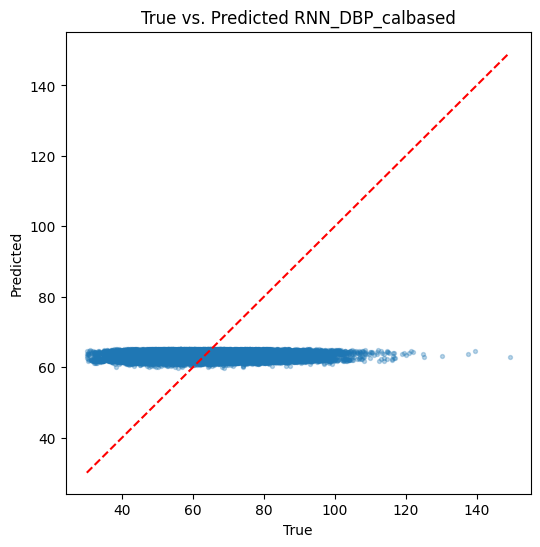

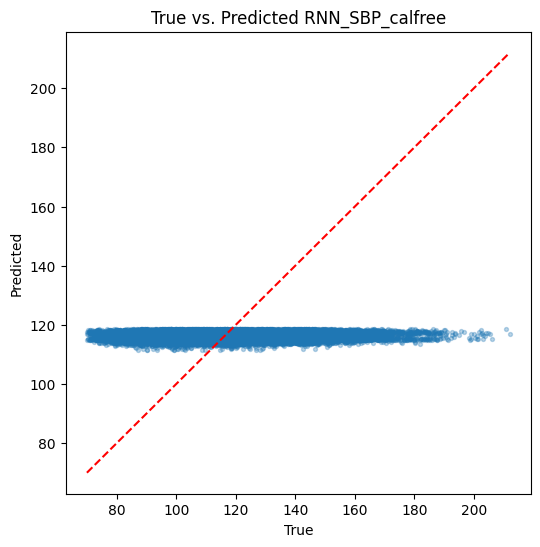

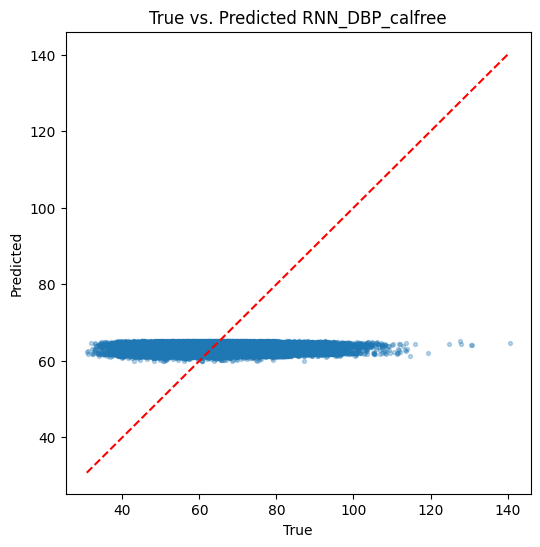

,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,LSTM,calbased,SBP,0.030511,18.598793,14.796780,0.002779,948.286433,23
1,LSTM,calbased,DBP,0.081586,11.838600,9.414016,0.006430,948.286433,23


,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,LSTM,calfree,SBP,0.301966,18.583920,14.857125,0.005113,948.286433,23
1,LSTM,calfree,DBP,0.123630,11.773511,9.371793,0.005693,948.286433,23


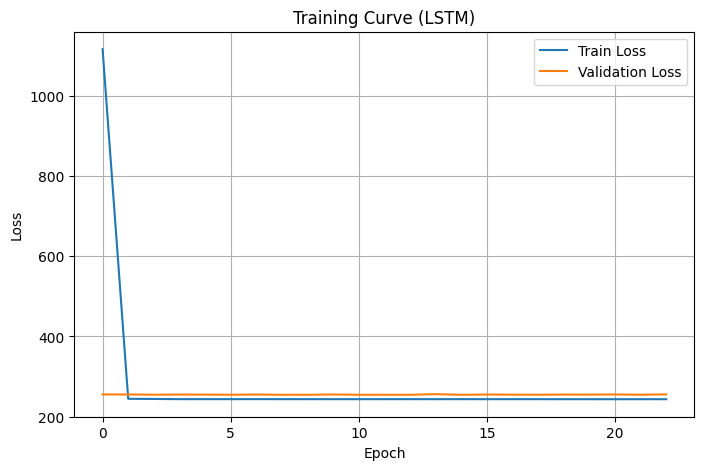

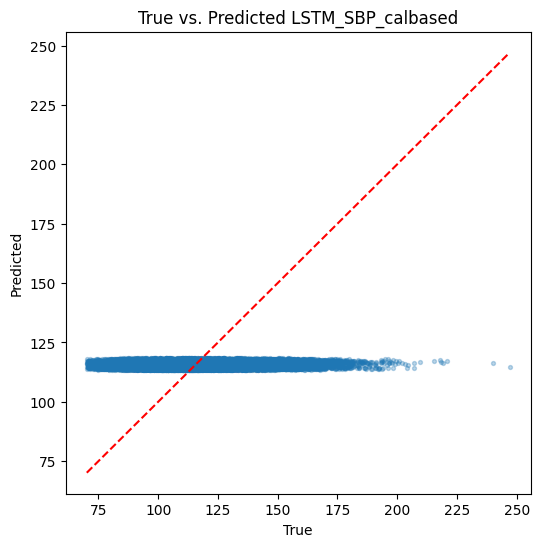

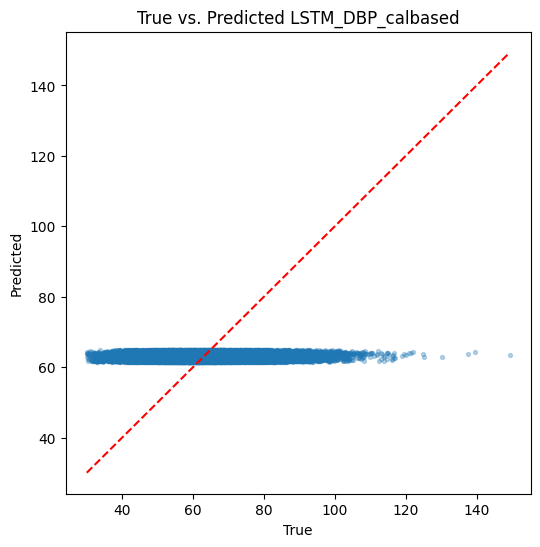

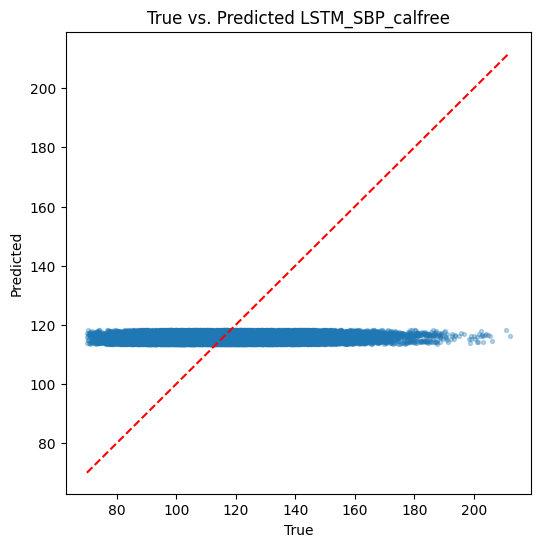

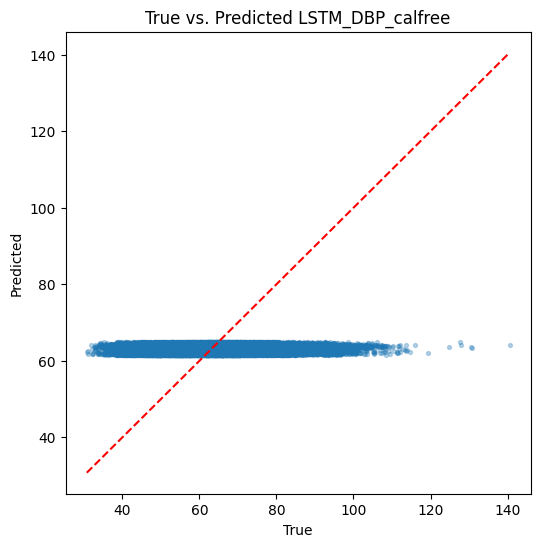

In [ ]:
model_list = [
    ("FCNN", FCNN),
    ("1D CNN", CNN1D),
    ("GRU", lambda: RNN(model_type='GRU')),
    ("RNN", lambda: RNN(model_type='RNN')),
    ("LSTM", lambda: RNN(model_type='LSTM')),
]

run_model(model_list, train_loader, val_loader, test_loader, test_loader_free)

,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,ConvGRU,calbased,SBP,-1.791342,14.209064,11.170362,0.408711,388.361905,13
1,ConvGRU,calbased,DBP,-0.712684,9.721010,7.650390,0.326515,388.361905,13


,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,ConvGRU,calfree,SBP,-2.431048,15.822892,12.475261,0.261945,388.361905,13
1,ConvGRU,calfree,DBP,-1.192816,10.353892,8.193581,0.220898,388.361905,13


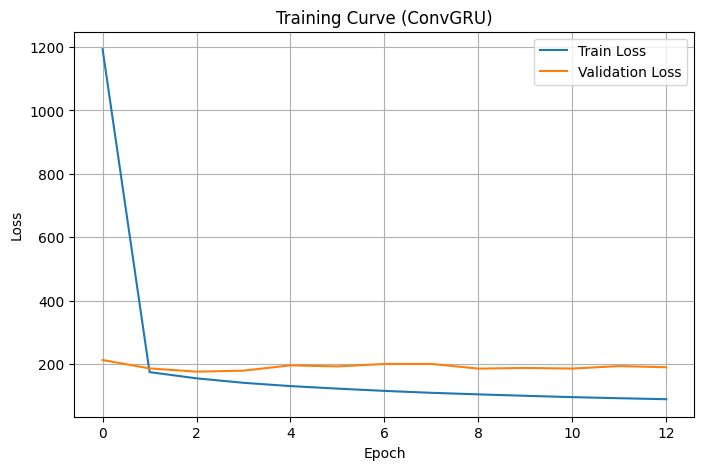

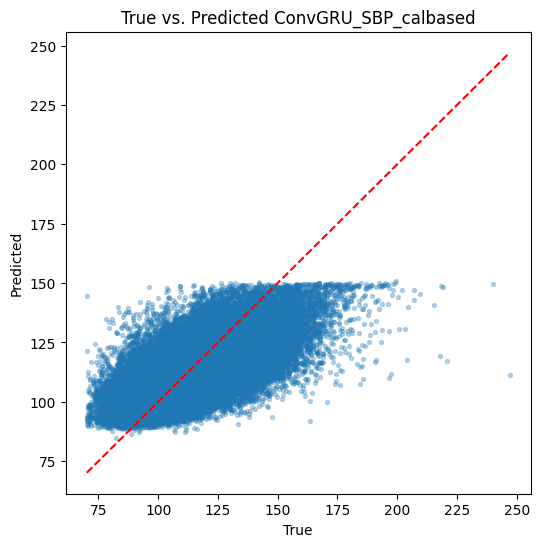

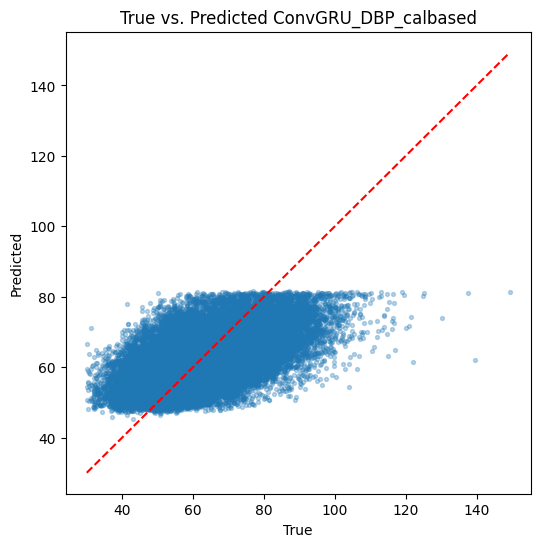

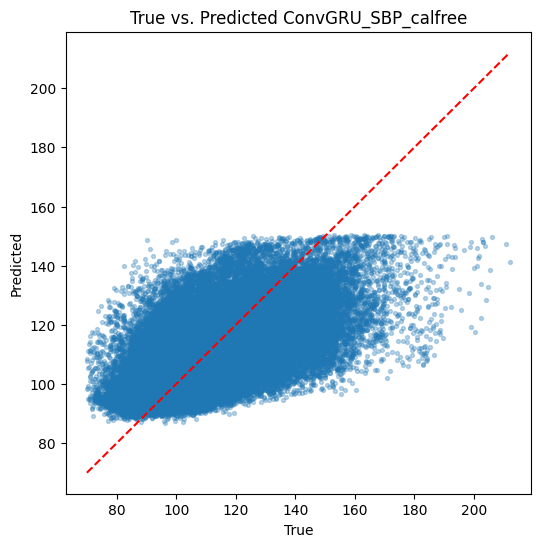

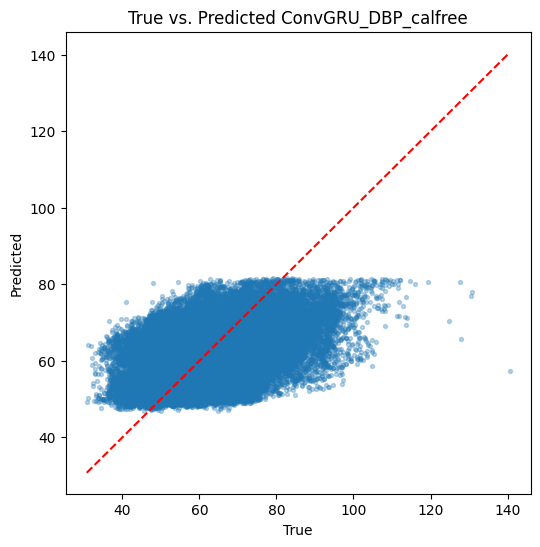

,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,ConvLSTM,calbased,SBP,-1.260145,14.52892,11.388919,0.386885,405.269438,14
1,ConvLSTM,calbased,DBP,-0.685650,9.90043,7.820927,0.301827,405.269438,14


,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,ConvLSTM,calfree,SBP,-1.641703,16.100922,12.629749,0.245642,405.269438,14
1,ConvLSTM,calfree,DBP,-1.013257,10.438464,8.235075,0.211127,405.269438,14


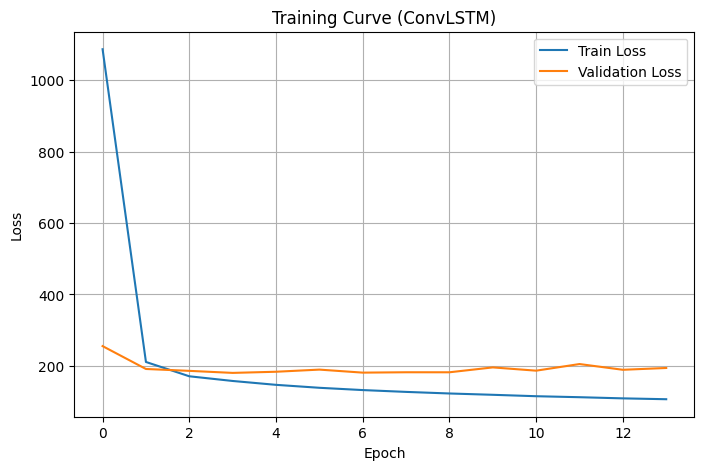

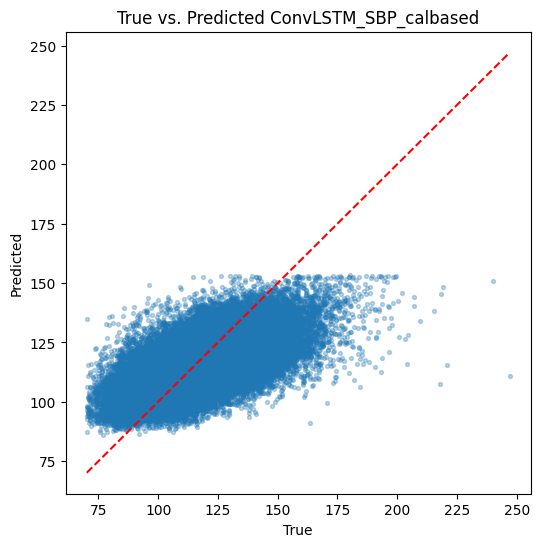

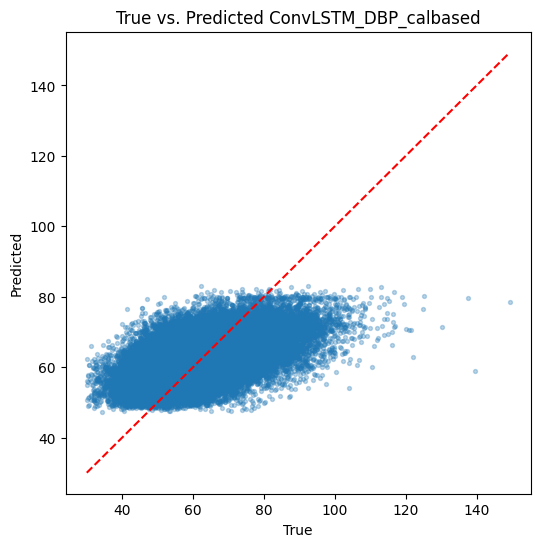

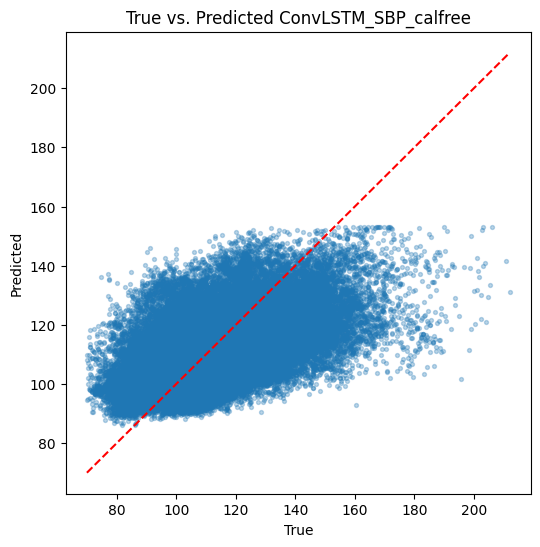

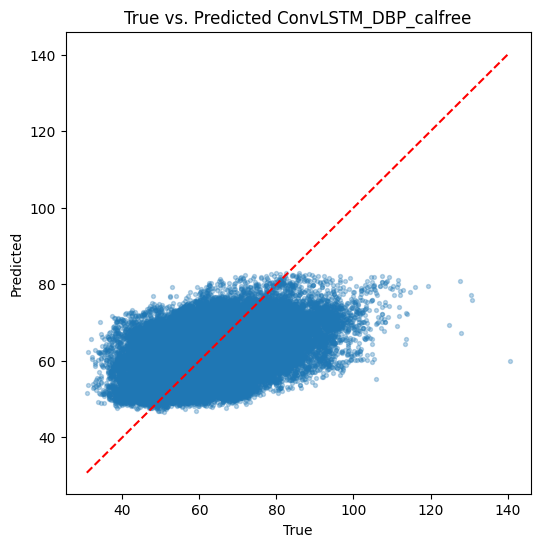

In [ ]:
from src.models import (
    ConvGRU,
    ConvLSTM,
)

model_list = [
    ("ConvGRU", ConvGRU),
    ("ConvLSTM", ConvLSTM),
]

run_model(model_list, train_loader, val_loader, test_loader, test_loader_free)

,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,Transformer,calbased,SBP,0.219445,13.902473,10.618221,0.442669,3236.218884,16
1,Transformer,calbased,DBP,-0.705281,9.366762,7.260111,0.374523,3236.218884,16


,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,Transformer,calfree,SBP,0.130379,17.001818,13.358562,0.167469,3236.218884,16
1,Transformer,calfree,DBP,-0.697400,11.116674,8.680593,0.110151,3236.218884,16


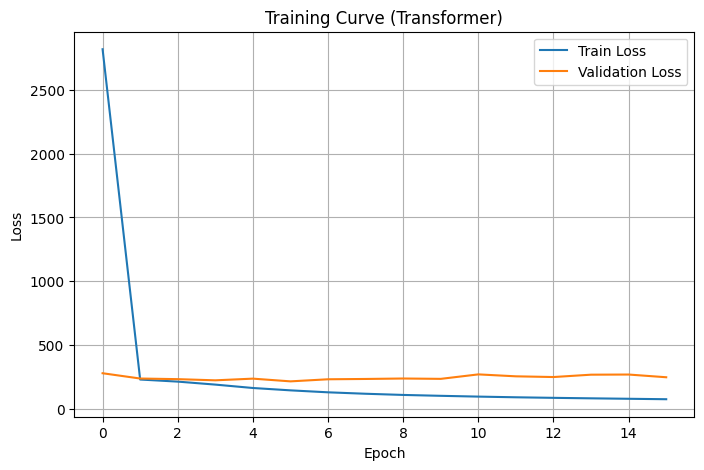

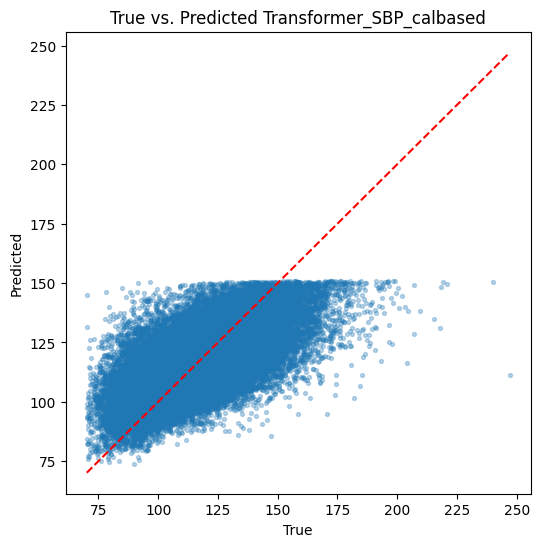

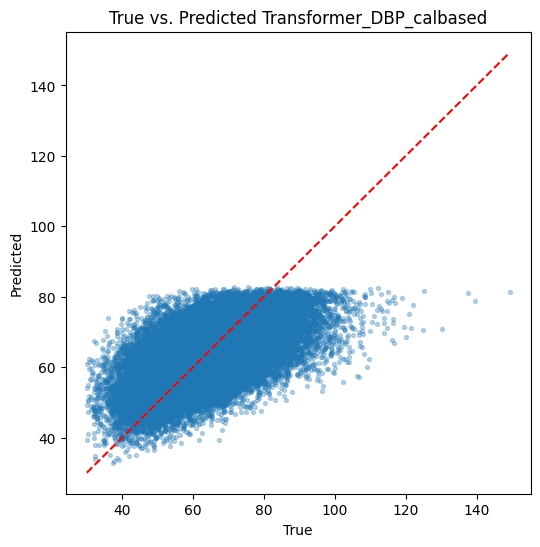

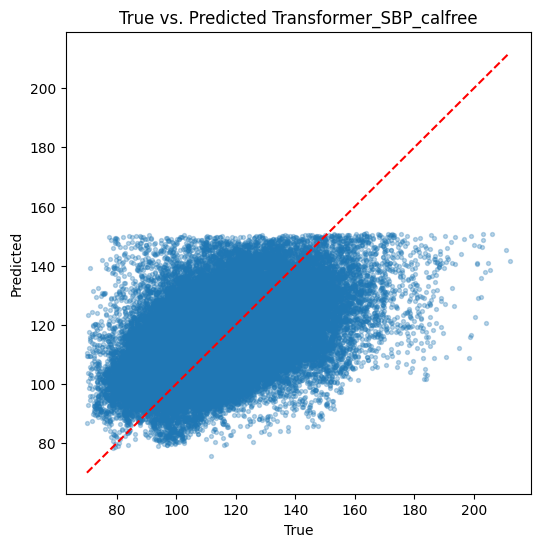

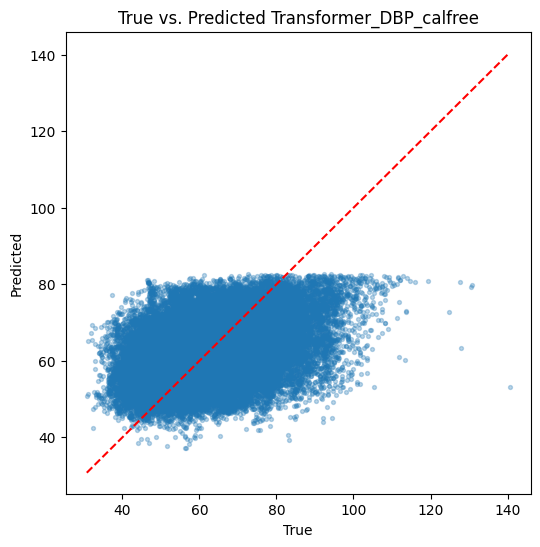

In [ ]:
model_list = [
    ("Transformer", Transformer),
]

run_model(model_list, train_loader, val_loader, test_loader, test_loader_free)

## Model Comparison

The models are compared using ME, SDE, MAE, and R². CNN-based and gated recurrent models are expected to capture waveform structure better than fully connected or vanilla recurrent models.

In [ ]:
metrics_df = pd.read_csv(metrics_path)
display(metrics_df)

,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,Ridge Regression,calbased,SBP,-0.038417,17.919249,14.211845,0.074317,205.863158,NaN
1,Ridge Regression,calbased,DBP,-0.031211,11.278760,8.975644,0.098215,205.863158,NaN
2,Ridge Regression,calfree,SBP,0.321489,17.882399,14.290911,0.078753,205.863158,NaN
3,Ridge Regression,calfree,DBP,0.070565,11.353824,9.029755,0.075383,205.863158,NaN
4,FCNN,calbased,SBP,-0.368225,17.434536,13.705942,0.123332,744.743210,49.0
5,FCNN,calbased,DBP,0.292592,11.275326,8.949271,0.098164,744.743210,49.0
6,FCNN,calfree,SBP,-0.276861,17.922197,14.169864,0.074726,744.743210,49.0
7,FCNN,calfree,DBP,0.263084,11.771340,9.345952,0.005673,744.743210,49.0
8,1D CNN,calbased,SBP,1.133685,15.014558,11.913191,0.346396,1816.932378,38.0
9,1D CNN,calbased,DBP,-1.311453,9.879764,7.844209,0.295865,1816.932378,38.0
